In [ ]:
import sys
from pathlib import Path 
import matplotlib.pyplot as plt 

import torch 
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
from dataset import get_val_transforms

ckpt_dir = Path("/Users/hawardizayee/Desktop/AMI/eb_jepa_data/checkpoints/image_jepa/dev_2026-08-24_20-49/resnet_vicreg_proj_bs256_ep300_ph1024_po1024_std0.0_cov0.0_seed42")

# Data 

In [ ]:
PKG_DIR = Path("/Users/hawardizayee/Desktop/AMI/eb_jepa/examples/my_image_jepa")
sys.path.insert(0, str(PKG_DIR))


data_dir = "/Users/hawardizayee/Desktop/AMI/eb_jepa/datasets/cifar10"

# clean (no-augmentation) val transform: ToTensor + CIFAR-10 normalize
val_dataset = CIFAR10(root=data_dir, train=False, download=False, transform=get_val_transforms())
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0)

# one batch to feed the model:  images (256, 3, 32, 32) normalized, labels (256,)
images, labels = next(iter(val_loader))

# CIFAR-10 normalization stats (to undo normalization for display)
MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
STD  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

def denorm(img):
    """(3,32,32) normalized tensor -> (32,32,3) array for imshow."""
    return (img * STD + MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

images.shape

# Model 

In [ ]:
latest = torch.load(ckpt_dir / "latest.pth.tar", map_location="cpu")
latest.keys()
latest["model_state_dict"].keys()

dict_keys(['epoch', 'step', 'model_state_dict', 'optimizer_state_dict', 'scaler_state_dict', 'linear_probe_state_dict', 'linear_val_acc'])

In [ ]:
from model import ResNet18, ImageSSL

# ckpt dir name encodes the config:  resnet ... ph1024_po1024  -> hidden/output = 1024
backbone = ResNet18()
model = ImageSSL(
    backbone,
    features_dim=backbone.features_dim,   # 512
    proj_hidden_dim=1024,
    proj_output_dim=1024,
)

model.load_state_dict(latest["model_state_dict"])

features: torch.Size([256, 512])  projections: torch.Size([256, 1024])


# Compare Cat and ship

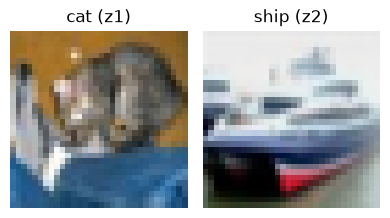

z1 (cat) : (1024,)
z2 (ship): (1024,)


In [29]:
model.eval()  # eval mode -> BatchNorm uses running stats (important for a 2-image batch)

# CIFAR-10 class ids
cat_id  = val_dataset.class_to_idx["cat"]    # 3
ship_id = val_dataset.class_to_idx["ship"]   # 8

# first cat and first ship in the loaded batch
cat_idx  = (labels == cat_id).nonzero()[0].item()
ship_idx = (labels == ship_id).nonzero()[0].item()

pair = torch.stack([images[cat_idx], images[ship_idx]])   # (2, 3, 32, 32)

with torch.no_grad():
    _, z = model(pair)          # projector output = the VICReg embedding

z1, z2 = z[0], z[1]             # z1 = cat, z2 = ship

# show the two images being compared
fig, axes = plt.subplots(1, 2, figsize=(4, 2.2))
for ax, i, name in zip(axes, [cat_idx, ship_idx], ["cat (z1)", "ship (z2)"]):
    ax.imshow(denorm(images[i])); ax.set_title(name); ax.axis("off")
plt.tight_layout(); plt.show()

print("z1 (cat) :", tuple(z1.shape))
print("z2 (ship):", tuple(z2.shape))

In [36]:
print(z1)
print(z2)

tensor([ 0.0093,  0.0182, -0.0300,  ...,  0.0293, -0.0301,  0.0215])
tensor([ 0.0093,  0.0182, -0.0300,  ...,  0.0293, -0.0301,  0.0215])


Collapse means the network maps every input into a tiny neighborhood — std ≈ 1e-9 across a batch. But "tiny neighborhood" isn't "single point."

In [ ]:
torch.allclose(z1,z2)       # tiny neighborhood 


False

# Collapsed embeddings 

In [ ]:
embeding_history = torch.load(ckpt_dir / "embedding_history.pt")

### Regarding HingeLoss 

In [74]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# reuse z (10x32), std (32,), class_names from the matplotlib cell above
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    row_heights=[0.9, 0.1], vertical_spacing=0.05,
)

# main heatmap: rows = class, cols = feature.
# ygap -> white gaps between rows (horizontal grid only); xgap=0 -> no vertical lines
fig.add_trace(
    go.Heatmap(
        z=z,
        y=class_names,
        colorscale="Viridis",
        xgap=0, ygap=2,
        colorbar=dict(title="embeddings", len=0.72, y=0.62),
    ),
    row=1, col=1,
)

# thin std bar: pinned to a healthy reference (0..1), so collapse-level std stays dark.
# xgap -> thin white separators between cells, so the 32 features read as discrete columns.
fig.add_trace(
    go.Heatmap(
        z=std[None, :],
        y=["per-feature std"],
        colorscale="Magma",
        zmin=0.0, zmax=1.0,
        xgap=1,
        showscale=True,
        colorbar=dict(title="std", len=0.35, y=0.10, thickness=16, tickvals=[0.0, 0.5, 1.0]),
    ),
    row=2, col=1,
)

fig.update_layout(
    plot_bgcolor="white",
    height=520, width=820,
)
fig.update_xaxes(title_text="feature", row=2, col=1)
fig.update_yaxes(autorange="reversed", row=1, col=1)  # class 0 on top, like imshow
fig.show()

### Regarding Cov Loss 

In [45]:
Z1 = embeding_history["z1_history"][-1]
Z1.shape

torch.Size([256, 1024])

In [58]:
Z1 = Z1 - Z1.mean(dim=0, keepdim=True)
cov = Z1.T @ Z1 
print(cov.shape ) 
print("----"*30)
print(cov)

torch.Size([1024, 1024])
------------------------------------------------------------------------------------------------------------------------
tensor([[ 5.7934e-16,  1.3481e-15,  1.3113e-15,  ..., -4.4490e-16,
         -1.6550e-15, -1.1861e-15],
        [ 1.3481e-15,  2.5718e-14,  1.5062e-14,  ..., -8.0176e-15,
         -2.5643e-14, -1.8272e-14],
        [ 1.3113e-15,  1.5062e-14,  9.6795e-15,  ..., -4.7149e-15,
         -1.5541e-14, -1.1126e-14],
        ...,
        [-4.4490e-16, -8.0176e-15, -4.7149e-15,  ...,  2.6836e-15,
          8.0765e-15,  5.7502e-15],
        [-1.6550e-15, -2.5643e-14, -1.5541e-14,  ...,  8.0765e-15,
          2.6297e-14,  1.8726e-14],
        [-1.1861e-15, -1.8272e-14, -1.1126e-14,  ...,  5.7502e-15,
          1.8726e-14,  1.3583e-14]])


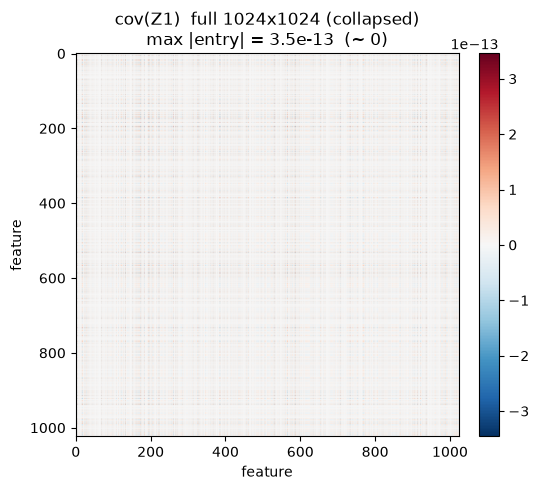

In [55]:
cov_np = cov.numpy()            # (1024, 1024) torch -> numpy for imshow

# autoscale the colormap to the data's OWN max, not a fixed reference.
# the entries are ~1e-14, so pinning to e.g. +/-1 would map everything to
# the center color (white). scaling to +/-M reveals the residual structure.
M = np.abs(cov_np).max()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cov_np, cmap="RdBu_r", vmin=-M, vmax=M)
ax.set_xlabel("feature")
ax.set_ylabel("feature")
ax.set_title(f"cov(Z1)  full 1024x1024 (collapsed)\nmax |entry| = {M:.1e}  (~ 0)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [ ]:
std = Z1.std(0)
print(std.min().item(), std.median().item(), std.max().item())  # orders of magnitude matter

# correlation matrix: decouples "is there variance?" from "is it redundant?"
# C = torch.corrcoef(Z1.T)   # ill-defined under collapse — informative in itself

# effective rank: catches *dimensional* collapse, which a uniform std bar won't
ev = torch.linalg.eigvalsh(torch.cov(Z1.T)).clamp(min=0)
p = ev / ev.sum()
print("eff. rank:", torch.exp(-(p * (p + 1e-12).log()).sum()).item())  # 1024 = ideal, ~1 = collapsed

5.390690116513497e-10 7.1120243028133245e-09 3.682975702190561e-08
eff. rank: 1.0955082178115845
